In [ ]:
import pandas as pd

sentiment_df = pd.read_csv('fear_greed_index.csv')
trades_df = pd.read_csv('historical_data.csv')

sentiment_df.columns = sentiment_df.columns.str.strip()
trades_df.columns = trades_df.columns.str.strip()

if 'date' in sentiment_df.columns:
    sentiment_df.rename(columns={'date': 'Date'}, inplace=True)

sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.date
trades_df['Date'] = pd.to_datetime(trades_df['Timestamp'], unit='ms').dt.date


In [22]:

merged_df = pd.merge(trades_df, sentiment_df, on='Date', how='left')


In [10]:

daily_metrics = merged_df.groupby(['Account', 'Date', 'classification']).agg(
    daily_PnL=('Closed PnL', 'sum'),
    num_trades=('Account', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    wins=('Closed PnL', lambda x: (x > 0).sum())
).reset_index()

daily_metrics['win_rate'] = daily_metrics['wins'] / daily_metrics['num_trades']


side_counts = merged_df.groupby(['Account', 'Date', 'Side']).size().unstack(fill_value=0).reset_index()

if 'B' in side_counts.columns and 'S' in side_counts.columns:
    side_counts['long_short_ratio'] = side_counts['B'] / (side_counts['S'] + 1e-9)
    daily_metrics = pd.merge(daily_metrics, side_counts[['Account', 'Date', 'long_short_ratio']], on=['Account', 'Date'])

print("Data successfully prepared! Here is a preview of the metrics:")
print(daily_metrics.head())

Data successfully prepared! Here is a preview of the metrics:
                                      Account        Date classification  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27          Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19           Fear   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27          Greed   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19           Fear   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03        Neutral   

      daily_PnL  num_trades  avg_trade_size  wins  win_rate  
0 -3.275059e+05         462    14810.891818    12  0.025974  
1  1.927736e+06        3356    16345.241940  1361  0.405542  
2  2.060745e+04         320     2492.749906   170  0.531250  
3  1.709873e+04        3533     1693.351684  1537  0.435041  
4 -1.000000e+00           5     6070.200000     0  0.000000  


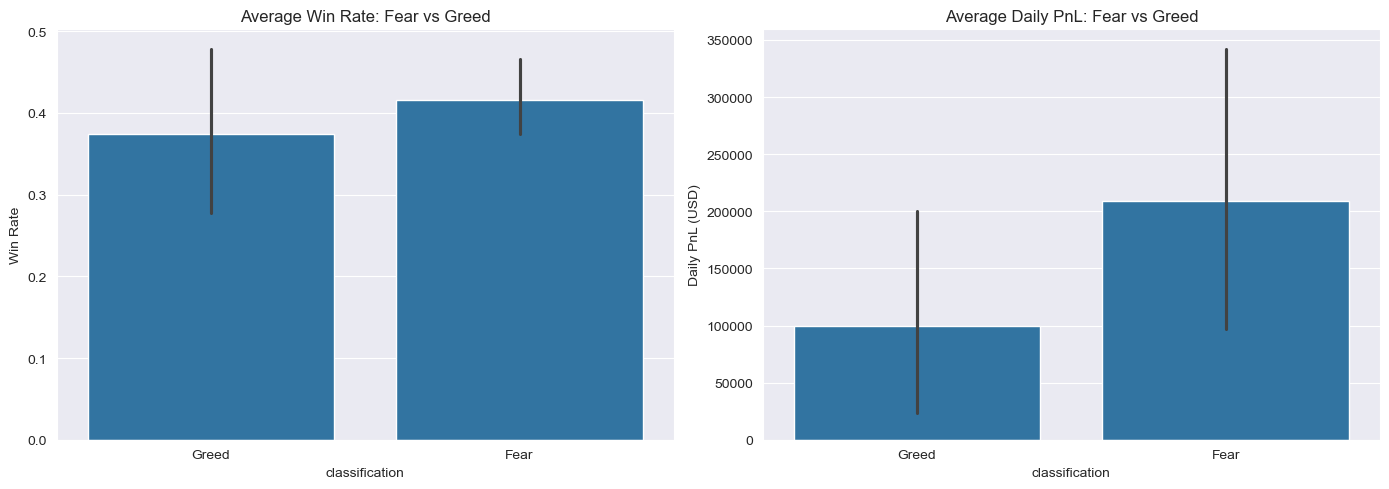

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
os.makedirs('images', exist_ok=True)

plot_data = daily_metrics[daily_metrics['classification'].isin(['Fear', 'Greed'])]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_data, x='classification', y='win_rate', ax=axes[0], estimator=np.mean)
axes[0].set_title('Average Win Rate: Fear vs Greed')
axes[0].set_ylabel('Win Rate')

sns.barplot(data=plot_data, x='classification', y='daily_PnL', ax=axes[1], estimator=np.mean)
axes[1].set_title('Average Daily PnL: Fear vs Greed')
axes[1].set_ylabel('Daily PnL (USD)')

plt.tight_layout()
plt.savefig('images/performance_by_sentiment.png')
plt.show()


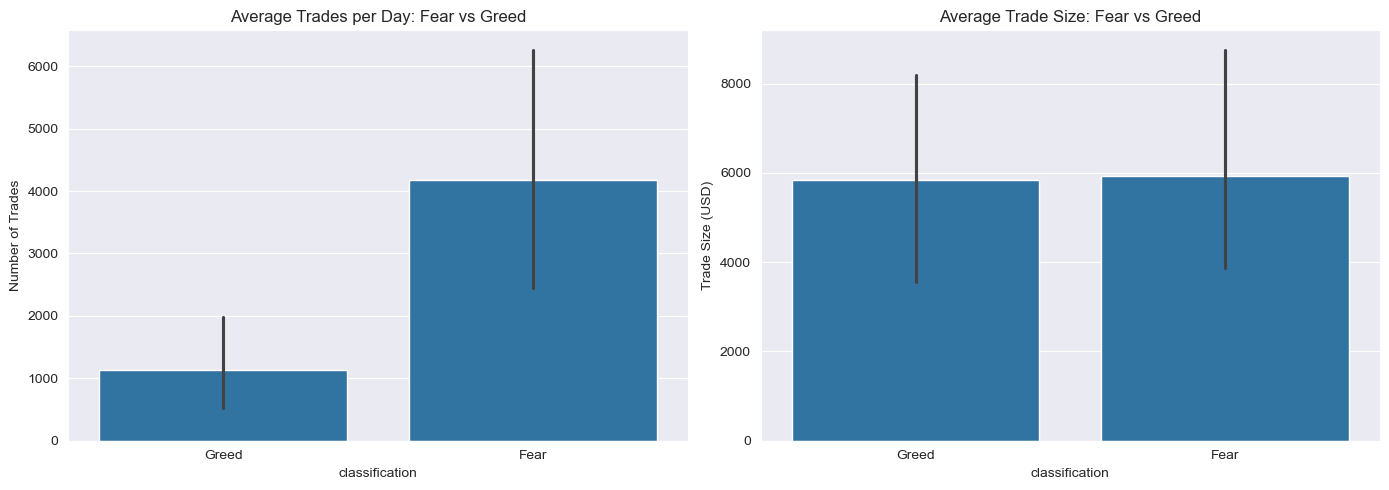

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_data, x='classification', y='num_trades', ax=axes[0], estimator=np.mean)
axes[0].set_title('Average Trades per Day: Fear vs Greed')
axes[0].set_ylabel('Number of Trades')

sns.barplot(data=plot_data, x='classification', y='avg_trade_size', ax=axes[1], estimator=np.mean)
axes[1].set_title('Average Trade Size: Fear vs Greed')
axes[1].set_ylabel('Trade Size (USD)')

plt.tight_layout()
plt.savefig('images/behavior_by_sentiment.png')
plt.show()

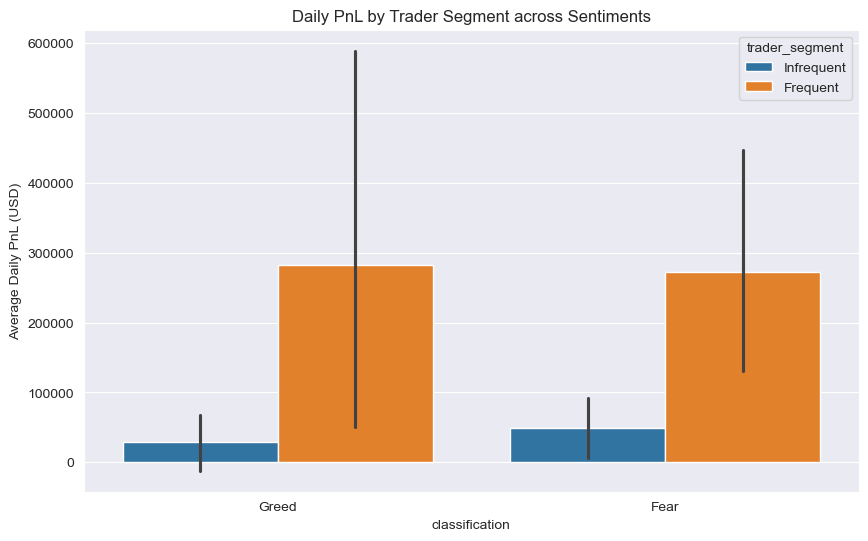

In [20]:
median_trades = plot_data['num_trades'].median()
plot_data['trader_segment'] = np.where(plot_data['num_trades'] > median_trades, 'Frequent', 'Infrequent')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='classification', y='daily_PnL', hue='trader_segment', estimator=np.mean)
plt.title('Daily PnL by Trader Segment across Sentiments')
plt.ylabel('Average Daily PnL (USD)')
plt.savefig('images/segmentation_pnl.png')
plt.show()

In [12]:
summary = plot_data.groupby('classification').agg(
    avg_pnl=('daily_PnL','mean'),
    avg_win_rate=('win_rate','mean'),
    avg_trades=('num_trades','mean'),
    avg_trade_size=('avg_trade_size','mean')
)

print(summary)

                      avg_pnl  avg_win_rate  avg_trades  avg_trade_size
classification                                                         
Fear            209372.662205      0.415878  4183.46875     5926.522723
Greed            99675.516731      0.374074  1134.03125     5839.310974


In [13]:
consistency = daily_metrics.groupby('Account')['daily_PnL'].std().reset_index()
consistency.columns = ['Account','pnl_volatility']

threshold = consistency['pnl_volatility'].median()

consistency['trader_type'] = np.where(
    consistency['pnl_volatility'] < threshold,
    'Consistent',
    'Inconsistent'
)

daily_metrics = pd.merge(daily_metrics, consistency[['Account','trader_type']], on='Account')

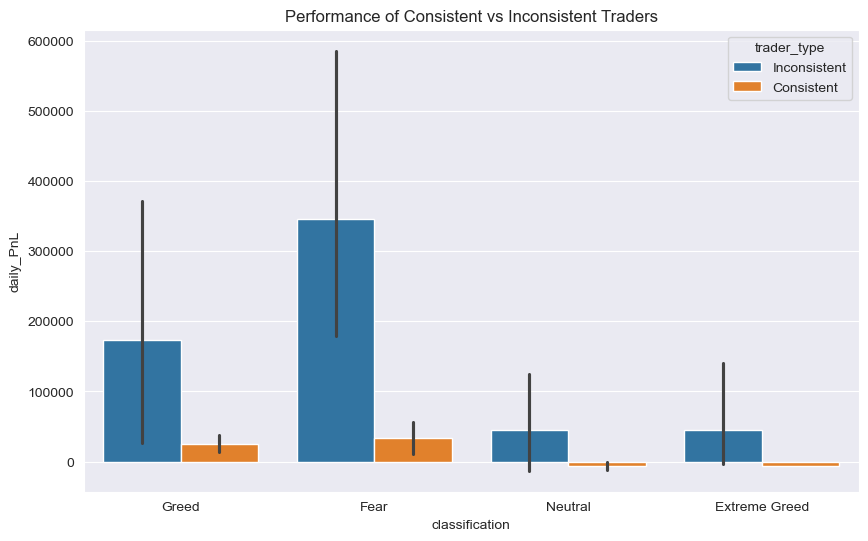

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=daily_metrics,
    x='classification',
    y='daily_PnL',
    hue='trader_type',
    estimator=np.mean
)

plt.title("Performance of Consistent vs Inconsistent Traders")
plt.savefig("images/consistency_analysis.png")
plt.show()